In [1]:
!pip install einops tqdm

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import random
from tqdm import tqdm

In [3]:
def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

In [4]:
p = 97   # common choice in grokking experiments

def generate_dataset(p):

    xs = []
    ys = []

    for i in range(p):
        for j in range(p):

            xs.append([i, j])
            ys.append((i + j) % p)

    xs = torch.tensor(xs)
    ys = torch.tensor(ys)

    return xs, ys

In [5]:
def train_val_split(xs, ys):

    N = xs.shape[0]
    idx = torch.randperm(N)

    split = N // 2

    train_idx = idx[:split]
    val_idx = idx[split:]

    return (
        xs[train_idx], ys[train_idx],
        xs[val_idx], ys[val_idx]
    )

In [6]:
class TransformerModel(nn.Module):

    def __init__(self, p, d_model=128, nhead=4, num_layers=2):

        super().__init__()

        self.p = p
        self.d_model = d_model

        # token embeddings
        self.token_embedding = nn.Embedding(p, d_model)

        # positional embeddings
        self.pos_embedding = nn.Embedding(2, d_model)

        # transformer encoder layer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=4*d_model,
            dropout=0.0,              # IMPORTANT
            activation="relu",
            batch_first=True,
            norm_first=False          # matches PyTorch default used in reproductions
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        # final classifier
        self.output = nn.Linear(d_model, p)

    def forward(self, x, return_hidden=False):

        B, T = x.shape

        # positional indices
        pos = torch.arange(T, device=x.device).unsqueeze(0).repeat(B,1)

        # embeddings
        x = self.token_embedding(x) + self.pos_embedding(pos)

        # transformer
        h = self.transformer(x)

        # use final token representation
        h_final = h[:, -1]

        logits = self.output(h_final)

        if return_hidden:
            return logits, h_final

        return logits

In [7]:
def accuracy(logits, y):

    preds = torch.argmax(logits, dim=1)

    return (preds == y).float().mean().item()

In [8]:
# def compute_ncc(representations, labels):

#     reps = representations.detach().cpu().numpy()
#     labels = labels.cpu().numpy()

#     mu = reps.mean(axis=0)

#     numerator = 0
#     denominator = 0

#     for c in np.unique(labels):

#         class_reps = reps[labels == c]

#         mu_c = class_reps.mean(axis=0)

#         numerator += ((class_reps - mu_c)**2).sum()
#         denominator += ((mu_c - mu)**2).sum()

#     return numerator / denominator


def compute_ncc(representations, labels):
    """
    Neural Collapse Clustering metric used in the paper.
    Pairwise class clustering ratio.
    """

    class_dict = {key.item(): [] for key in torch.unique(labels)}

    for rep, label in zip(representations, labels):
        class_dict[label.item()].append(rep)

    mean_var_dict = {}

    for key, value in class_dict.items():
        value = torch.stack(value)

        mu = torch.mean(value, dim=0)
        var = torch.mean(torch.stack([torch.linalg.norm(f - mu) ** 2 for f in value]))

        mean_var_dict[key] = (mu, var)

    pairwise_vals = []

    classes = list(mean_var_dict.keys())

    for i in range(len(classes)):
        for j in range(len(classes)):

            if i == j:
                continue

            mu1, var1 = mean_var_dict[classes[i]]
            mu2, var2 = mean_var_dict[classes[j]]

            val = (var1 + var2) / (2 * torch.linalg.norm(mu1 - mu2) ** 2)

            pairwise_vals.append(val)

    ncc = torch.mean(torch.stack(pairwise_vals))

    return ncc.item()

In [9]:
# def compute_relative_flatness(model, loss_fn, xs, ys, eps=1e-3):

#     with torch.no_grad():

#         logits = model(xs)
#         original_loss = loss_fn(logits, ys)

#         backup = [p.clone() for p in model.parameters()]

#         for p in model.parameters():
#             p += eps * torch.randn_like(p)

#         logits = model(xs)
#         perturbed_loss = loss_fn(logits, ys)

#         for p, b in zip(model.parameters(), backup):
#             p.copy_(b)

#     rf = (perturbed_loss - original_loss) / original_loss

#     return rf.item()
def compute_relative_flatness(model, features, logits):

    probs = torch.softmax(logits, dim=1)

    hessian_first = torch.sum(probs * (1 - probs), dim=1)

    hessian_second = torch.sum(features * features, dim=1)

    W = model.output.weight
    weights_norm = torch.linalg.norm(W)

    hessian = hessian_first * hessian_second

    sharpness2 = weights_norm * weights_norm * hessian

    return torch.mean(sharpness2).item()

In [12]:
def train(seed):

    set_seed(seed)

    xs, ys = generate_dataset(p)

    x_train, y_train, x_val, y_val = train_val_split(xs, ys)

    device = "cuda" if torch.cuda.is_available() else "cpu"

    model = TransformerModel(p).to(device)

    x_train = x_train.to(device)
    y_train = y_train.to(device)

    x_val = x_val.to(device)
    y_val = y_val.to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=1e-4,
        weight_decay=1.0
    )

    loss_fn = nn.CrossEntropyLoss()

    train_accs = []
    val_accs = []
    nccs = []
    flatness = []

    steps = 100000*2

    for step in tqdm(range(steps)):

        logits, hidden = model(x_train, return_hidden=True)

        loss = loss_fn(logits, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if step % 100 == 0:

            with torch.no_grad():

                train_acc = accuracy(logits, y_train)

                val_logits, val_hidden = model(x_val, return_hidden=True)

                val_acc = accuracy(val_logits, y_val)

                # NCC uses hidden representations
                ncc = compute_ncc(val_hidden, y_val)

                # Relative flatness uses hidden features + logits
                rf = compute_relative_flatness(
                    model,
                    val_hidden,
                    val_logits
                )

                train_accs.append(train_acc)
                val_accs.append(val_acc)
                nccs.append(ncc)
                flatness.append(rf)

    return train_accs, val_accs, nccs, flatness

In [13]:
results = []

for seed in [0]:

    r = train(seed)

    results.append(r)

100%|██████████| 200000/200000 [2:43:04<00:00, 20.44it/s]  


In [14]:
train_acc = np.mean([r[0] for r in results], axis=0)
val_acc = np.mean([r[1] for r in results], axis=0)
ncc = np.mean([r[2] for r in results], axis=0)
flatness = np.mean([r[3] for r in results], axis=0)

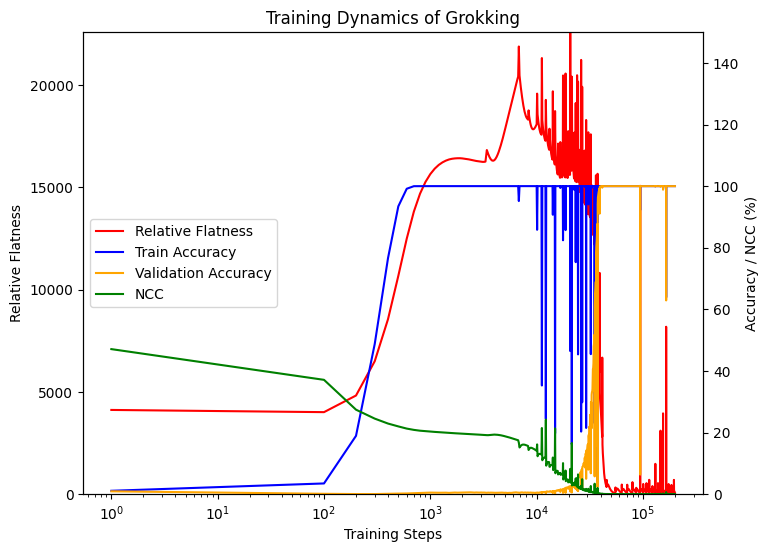

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# training steps recorded every 1000 iterations
steps = np.arange(len(train_acc)) * 100
steps[0] = 1   # log scale cannot plot 0

# convert to percentage
train_acc_pct = np.array(train_acc) * 100
val_acc_pct = np.array(val_acc) * 100
ncc_pct = np.array(ncc)

fig, ax1 = plt.subplots(figsize=(8,6))

# LEFT AXIS — Relative Flatness
ax1.plot(steps, flatness, color="red", label="Relative Flatness")
ax1.set_ylabel("Relative Flatness")
ax1.set_ylim(0,max(flatness))

# X axis (log scale)
ax1.set_xscale("log")
ax1.set_xlabel("Training Steps")

# RIGHT AXIS — Accuracy + NCC
ax2 = ax1.twinx()

ax2.plot(steps, train_acc_pct, color="blue", label="Train Accuracy")
ax2.plot(steps, val_acc_pct, color="orange", label="Validation Accuracy")
ax2.plot(steps, ncc_pct, color="green", label="NCC")

ax2.set_ylabel("Accuracy / NCC (%)")
ax2.set_ylim(0,150)

# combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax2.legend(lines1 + lines2, labels1 + labels2, loc="center left")

plt.title("Training Dynamics of Grokking")
plt.show()

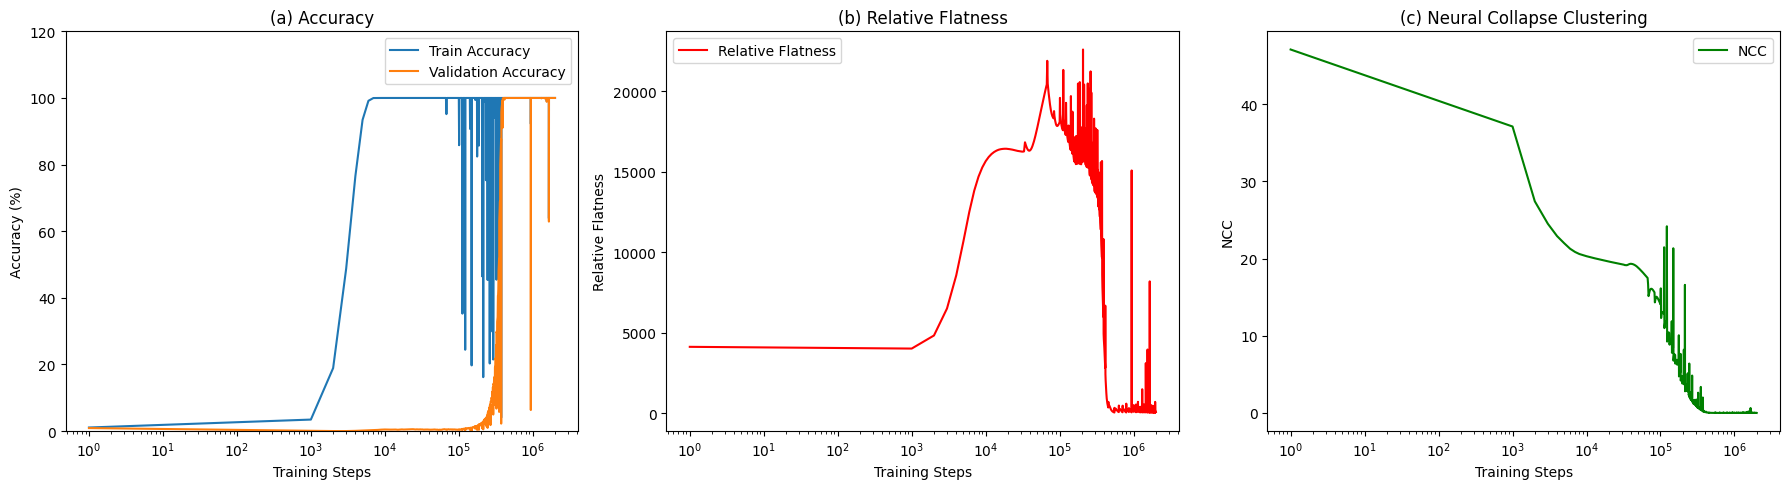

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# steps recorded every 1000 iterations
steps = np.arange(len(train_acc)) * 1000
steps[0] = 1   # log scale cannot show 0

fig, axes = plt.subplots(1,3, figsize=(18,5))

# ------------------------------------------------
# (a) Accuracy
# ------------------------------------------------

axes[0].plot(steps, np.array(train_acc)*100, label="Train Accuracy")
axes[0].plot(steps, np.array(val_acc)*100, label="Validation Accuracy")

axes[0].set_xscale("log")
axes[0].set_xlabel("Training Steps")
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_ylim(0,120)
axes[0].set_title("(a) Accuracy")

axes[0].legend()


# ------------------------------------------------
# (b) Relative Flatness
# ------------------------------------------------

axes[1].plot(steps, flatness, label="Relative Flatness", color="red")

axes[1].set_xscale("log")
axes[1].set_xlabel("Training Steps")
axes[1].set_ylabel("Relative Flatness")
axes[1].set_title("(b) Relative Flatness")

axes[1].legend()


# ------------------------------------------------
# (c) NCC
# ------------------------------------------------

axes[2].plot(steps, ncc, label="NCC", color="green")

axes[2].set_xscale("log")
axes[2].set_xlabel("Training Steps")
axes[2].set_ylabel("NCC")
axes[2].set_title("(c) Neural Collapse Clustering")

axes[2].legend()


plt.tight_layout()
plt.show()